In [ ]:
!pip install mediapipe

In [ ]:
# Mount Google Drive
from google.colab import drive
print("Mounting Google Drive...")
drive.mount('/content/drive')

# Change to your working directory
import os
working_dir = '/content/drive/MyDrive/lipreading/lrw/lrw_dataset'
try:
    os.chdir(working_dir)
    print(f"Changed directory to: {os.getcwd()}")
except FileNotFoundError:
    print(f"Error: Could not change directory to '{working_dir}'. Please ensure it exists.")

# Imports
import tensorflow as tf
import mediapipe as mp
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
from IPython.display import clear_output # For animation

print("\n--- Environment Check ---")
print("TensorFlow Version:", tf.__version__)
print("OpenCV Version:", cv2.__version__)
print("MediaPipe Version:", mp.__version__)
print("NumPy Version:", np.__version__)


# Check GPU
print("\n--- GPU Check ---")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
  try:
    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    logical_gpus = tf.config.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    print("GPU Name:", tf.test.gpu_device_name())
    device = '/GPU:0'
  except RuntimeError as e:
    print(e)
    device = '/CPU:0'
else:
    print("No GPU detected, using CPU.")
    device = '/CPU:0'

print(f"Using device: {device}")
print("\nSetup Cell Complete.")

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Changed directory to: /content/drive/MyDrive/lipreading/lrw/lrw_dataset

--- Environment Check ---
TensorFlow Version: 2.18.0
OpenCV Version: 4.11.0
MediaPipe Version: 0.10.21
NumPy Version: 1.26.4

--- GPU Check ---
1 Physical GPUs, 1 Logical GPUs
GPU Name: /device:GPU:0
Using device: /GPU:0

Setup Cell Complete.


In [ ]:
print("\n--- Parameters & Path Verification ---")

# LRW dataset root path (should be the current working directory after os.chdir)
lrw_root_path = os.getcwd()

# --- Parameters ---
BATCH_SIZE = 128       # Can be adjusted later for training
IMG_WIDTH = 88       # Target width after cropping
IMG_HEIGHT = 88      # Target height after cropping
NUM_FRAMES = 29       # LRW videos have fixed 29 frames
NUM_CLASSES = 500     # LRW has 500 word classes
GRAYSCALE = True      # Process video in grayscale
FACE_MESH_MARGIN = 0.3 # Margin around detected mouth landmarks for cropping (adjust if needed)

# --- Derived Parameters ---
IMG_SHAPE = (IMG_HEIGHT, IMG_WIDTH, 1 if GRAYSCALE else 3)
# Expected input shape for the model (T, H, W, C) - TensorFlow often uses channels last
INPUT_SHAPE = (NUM_FRAMES, IMG_HEIGHT, IMG_WIDTH, 1 if GRAYSCALE else 3)

print(f"LRW dataset path assumed to be: {lrw_root_path}")
print(f"Expected model input shape: {INPUT_SHAPE}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Mouth crop margin: {FACE_MESH_MARGIN}")

# --- Verify Dataset Structure ---
lipread_subdir = os.path.join(lrw_root_path, "lipread_mp4")
if os.path.exists(lipread_subdir) and os.path.isdir(lipread_subdir):
    print(f"Found subdirectory: '{lipread_subdir}'")
    # Optional: Check for a specific word directory
    example_word_dir = os.path.join(lipread_subdir, "ABOUT")
    if os.path.exists(example_word_dir) and os.path.isdir(example_word_dir):
         print(f"Found example word directory: '{example_word_dir}'")
    else:
         print(f"Warning: Example word directory ('ABOUT') not found in '{lipread_subdir}'.")
else:
    print(f"ERROR: Subdirectory 'lipread_mp4' NOT found in '{lrw_root_path}'. Please check the dataset structure.")

print("\nParameter Cell Complete.")


--- Parameters & Path Verification ---
LRW dataset path assumed to be: /content/drive/MyDrive/lipreading/lrw/lrw_dataset
Expected model input shape: (29, 88, 88, 1)
Number of classes: 500
Mouth crop margin: 0.3
Found subdirectory: '/content/drive/MyDrive/lipreading/lrw/lrw_dataset/lipread_mp4'
Found example word directory: '/content/drive/MyDrive/lipreading/lrw/lrw_dataset/lipread_mp4/ABOUT'

Parameter Cell Complete.


In [ ]:
print("\n--- Preprocessing Function Definitions ---")

MOUTH_LANDMARKS_OUTER = [61, 146, 91, 181, 84, 17, 314, 405, 321, 375, 291]
MOUTH_LANDMARKS_TO_USE = MOUTH_LANDMARKS_OUTER

def process_frame(frame, face_mesh, margin=0.3, target_size=(88, 88)):
    """
    Process a single frame: detect face, extract the mouth region, and preprocess it.

    Parameters:
        frame (np.array): Input frame in BGR format.
        face_mesh: An instance of Mediapipe Face Mesh.
        margin (float): Fraction to expand the bounding box.
        target_size (tuple): Output image size (width, height).

    Returns:
        processed_frame (np.array): Preprocessed grayscale image of the mouth region
                                    with shape (target_size[1], target_size[0], 1),
                                    or None if detection fails.
    """
    h, w, _ = frame.shape
    # Convert BGR image to RGB for Mediapipe processing.
    img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    img_rgb.flags.writeable = False # Improve performance
    results = face_mesh.process(img_rgb)
    img_rgb.flags.writeable = True

    if not results.multi_face_landmarks:
        return None  # Return None if no face landmarks are detected.

    # Use the first detected face.
    face_landmarks = results.multi_face_landmarks[0]

    # Extract pixel coordinates for each mouth landmark.
    pts = []
    for idx in MOUTH_LANDMARKS_TO_USE:
        # Ensure index is within the valid range for the specific landmark model
        if idx < len(face_landmarks.landmark):
             lm = face_landmarks.landmark[idx]
             pts.append((int(lm.x * w), int(lm.y * h)))

    if not pts: # If no valid mouth landmarks were found for this face
        return None

    pts = np.array(pts)
    x_min, y_min = np.min(pts, axis=0)
    x_max, y_max = np.max(pts, axis=0)

    # Calculate center and dimensions of the initial box
    center_x = (x_min + x_max) / 2
    center_y = (y_min + y_max) / 2
    box_width = x_max - x_min
    box_height = y_max - y_min

    # Determine the side length for a square box based on the larger dimension
    crop_size = max(box_width, box_height)

    # Add margin (percentage of the crop size)
    crop_size_margin = int(crop_size * (1 + 2 * margin)) # Total size including margin on both sides

    # Calculate new min/max for the square box with margin, centered
    x_min_sq = int(center_x - crop_size_margin / 2)
    x_max_sq = int(center_x + crop_size_margin / 2)
    y_min_sq = int(center_y - crop_size_margin / 2)
    y_max_sq = int(center_y + crop_size_margin / 2)

    # Ensure coordinates are within image bounds
    x_min_sq = max(0, x_min_sq)
    y_min_sq = max(0, y_min_sq)
    x_max_sq = min(w, x_max_sq)
    y_max_sq = min(h, y_max_sq)

    # Crop the mouth region using the square box. Check if crop is valid.
    if y_min_sq >= y_max_sq or x_min_sq >= x_max_sq:
        # print(f"Warning: Invalid crop dimensions [{y_min_sq}:{y_max_sq}, {x_min_sq}:{x_max_sq}]. Skipping frame.")
        return None

    cropped = frame[y_min_sq:y_max_sq, x_min_sq:x_max_sq]

    if cropped.size == 0:
        return None

    # Resize to the target size.
    resized = cv2.resize(cropped, target_size, interpolation=cv2.INTER_LINEAR) # Use linear interpolation

    # Convert to grayscale.
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

    # Expand dimensions to add a channel axis.
    processed_frame = np.expand_dims(gray, axis=-1)

    return processed_frame

print("process_frame function defined.")


--- Preprocessing Function Definitions ---
process_frame function defined.


In [ ]:
# Cell 5 (Modified)

print("\n--- Video Preprocessing Function Definition (Revised) ---")

def preprocess_video(video_path, num_frames=NUM_FRAMES, target_size=(IMG_WIDTH, IMG_HEIGHT), margin=FACE_MESH_MARGIN):
    """
    Preprocess a video to extract the mouth region from each frame.
    Accepts video_path as bytes (from tf.numpy_function).
    """
    # Decode the byte string path passed by tf.numpy_function
    if isinstance(video_path, bytes):
        video_path_str = video_path.decode('utf-8')
    else:
        # Handle case if it's already a string (e.g., direct call)
        video_path_str = str(video_path)

    cap = cv2.VideoCapture(video_path_str) # Use the decoded string path
    if not cap.isOpened():
        print(f"Error: Could not open video file: {video_path_str}")
        return np.zeros((num_frames, target_size[1], target_size[0], 1), dtype=np.uint8)

    frames = []
    processed_frame_count = 0

    # Initialize Mediapipe Face Mesh.
    mp_face_mesh = mp.solutions.face_mesh
    with mp_face_mesh.FaceMesh(static_image_mode=True,
                               max_num_faces=1,
                               refine_landmarks=False,
                               min_detection_confidence=0.5) as face_mesh:
        while processed_frame_count < num_frames:
            ret, frame = cap.read()
            if not ret:
                break # End of video or error

            processed = process_frame(frame, face_mesh, margin=margin, target_size=target_size)

            if processed is None:
                processed = np.zeros((target_size[1], target_size[0], 1), dtype=np.uint8)

            frames.append(processed)
            processed_frame_count += 1

    cap.release()

    # Handle case where video had fewer frames than num_frames
    actual_frames = len(frames)
    if actual_frames == 0:
         print(f"Error: No frames could be processed from video: {video_path_str}")
         return np.zeros((num_frames, target_size[1], target_size[0], 1), dtype=np.uint8)

    if actual_frames < num_frames:
        last_frame = frames[-1]
        for _ in range(num_frames - actual_frames):
            frames.append(last_frame)

    video_array = np.array(frames[:num_frames], dtype=np.uint8)

    # Final check on shape
    expected_shape = (num_frames, target_size[1], target_size[0], 1)
    if video_array.shape != expected_shape:
        print(f"Warning: Final video array shape mismatch for {video_path_str}. Expected {expected_shape}, got {video_array.shape}. Returning zeros.")
        return np.zeros(expected_shape, dtype=np.uint8)

    return video_array

print("preprocess_video function (revised for tf.numpy_function) defined.")


--- Video Preprocessing Function Definition (Revised) ---
preprocess_video function (revised for tf.numpy_function) defined.


In [ ]:
print("\n--- Visualization Function Definition ---")

def process_frame_with_intermediates(frame, face_mesh, margin=0.3, target_size=(88, 88)):
    """
    Process a single frame and return intermediate images for visualization.

    Returns a dictionary containing:
      - "original_frame_rgb": Original frame in RGB.
      - "original_with_box": Original frame (RGB) with the mouth bounding box drawn.
      - "original_with_sq_box": Original frame (RGB) with the final square crop box drawn.
      - "cropped_rgb": Cropped mouth region (from square box) in RGB.
      - "resized_rgb": Resized mouth region in RGB.
      - "gray": Final grayscale image after resizing.
      - "landmarks_overlay": Original RGB with landmarks plotted.
    Or None if detection fails.
    """
    h, w, _ = frame.shape
    # Convert BGR to RGB for visualization and Mediapipe processing.
    img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    img_rgb.flags.writeable = False # Improve performance
    results = face_mesh.process(img_rgb)
    img_rgb.flags.writeable = True

    if not results.multi_face_landmarks:
        return None  # No landmarks detected.

    # Use the first detected face.
    face_landmarks = results.multi_face_landmarks[0]

    # --- Draw Landmarks ---
    landmarks_overlay = img_rgb.copy()
    for idx in MOUTH_LANDMARKS_TO_USE:
         if idx < len(face_landmarks.landmark):
            lm = face_landmarks.landmark[idx]
            center_coordinates = (int(lm.x * w), int(lm.y * h))
            cv2.circle(landmarks_overlay, center_coordinates, radius=2, color=(0, 255, 0), thickness=-1)

    # Extract pixel coordinates for mouth bounding box.
    pts = []
    for idx in MOUTH_LANDMARKS_TO_USE:
         if idx < len(face_landmarks.landmark):
            lm = face_landmarks.landmark[idx]
            pts.append((int(lm.x * w), int(lm.y * h)))

    if not pts: return None

    pts = np.array(pts)
    x_min, y_min = np.min(pts, axis=0)
    x_max, y_max = np.max(pts, axis=0)

    # Create a copy for drawing the initial bounding box.
    original_with_box = img_rgb.copy()
    cv2.rectangle(original_with_box, (x_min, y_min), (x_max, y_max), (0, 0, 255), 2) # Red box

    # Calculate center and dimensions for square crop
    center_x = (x_min + x_max) / 2
    center_y = (y_min + y_max) / 2
    box_width = x_max - x_min
    box_height = y_max - y_min
    crop_size = max(box_width, box_height)
    crop_size_margin = int(crop_size * (1 + 2 * margin)) # Total size including margin

    # Calculate square box coordinates
    x_min_sq = int(center_x - crop_size_margin / 2)
    x_max_sq = int(center_x + crop_size_margin / 2)
    y_min_sq = int(center_y - crop_size_margin / 2)
    y_max_sq = int(center_y + crop_size_margin / 2)

    # Ensure coordinates are within image bounds
    x_min_sq_clipped = max(0, x_min_sq)
    y_min_sq_clipped = max(0, y_min_sq)
    x_max_sq_clipped = min(w, x_max_sq)
    y_max_sq_clipped = min(h, y_max_sq)

    # Draw the final square cropping box
    original_with_sq_box = img_rgb.copy()
    cv2.rectangle(original_with_sq_box, (x_min_sq_clipped, y_min_sq_clipped), (x_max_sq_clipped, y_max_sq_clipped), (0, 255, 0), 2) # Green box

    # Crop the mouth region using the clipped square box. Check validity.
    if y_min_sq_clipped >= y_max_sq_clipped or x_min_sq_clipped >= x_max_sq_clipped:
        return None # Invalid crop dimensions

    cropped = frame[y_min_sq_clipped:y_max_sq_clipped, x_min_sq_clipped:x_max_sq_clipped]

    if cropped.size == 0: return None # Empty crop

    cropped_rgb = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)

    # Resize the cropped image.
    resized = cv2.resize(cropped, target_size, interpolation=cv2.INTER_LINEAR)
    resized_rgb = cv2.resize(cropped_rgb, target_size, interpolation=cv2.INTER_LINEAR)

    # Convert the resized image to grayscale.
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

    # Return all intermediate results in a dictionary.
    return {
        "original_frame_rgb": img_rgb,
        "landmarks_overlay": landmarks_overlay,
        "original_with_box": original_with_box,
        "original_with_sq_box": original_with_sq_box,
        "cropped_rgb": cropped_rgb,
        "resized_rgb": resized_rgb,
        "gray": gray
    }

print("process_frame_with_intermediates function defined.")


--- Visualization Function Definition ---
process_frame_with_intermediates function defined.


In [ ]:
print("\n--- Testing Video Preprocessing ---")

# Construct an example video path (adjust word/set/number if needed)
example_word = "UNTIL"
example_set = "train"
example_file_num = "00001"
example_video_path = os.path.join(
    lrw_root_path,
    "lipread_mp4",
    example_word,
    example_set,
    f"{example_word}_{example_file_num}.mp4" # Use the original .mp4
)

print(f"Attempting to preprocess video: {example_video_path}")

if not os.path.exists(example_video_path):
    print("Error: Example video file not found. Please check the path and dataset structure.")
else:
    start_time = time.time()
    processed_video = preprocess_video(example_video_path, num_frames=NUM_FRAMES, target_size=(IMG_WIDTH, IMG_HEIGHT), margin=FACE_MESH_MARGIN)
    end_time = time.time()

    if processed_video is not None:
        print(f"\nPreprocessing successful! Time taken: {end_time - start_time:.2f} seconds.")
        # Print the final output shape and data type.
        print("Processed video shape:", processed_video.shape)
        print("Data type:", processed_video.dtype) # Should be uint8
        print("Min/Max pixel values:", np.min(processed_video), np.max(processed_video))
    else:
        print("\nPreprocessing failed for the example video.")

print("\nPreprocessing Test Cell Complete.")


--- Testing Video Preprocessing ---
Attempting to preprocess video: /content/drive/MyDrive/lipreading/lrw/lrw_dataset/lipread_mp4/UNTIL/train/UNTIL_00001.mp4

Preprocessing successful! Time taken: 0.23 seconds.
Processed video shape: (29, 88, 88, 1)
Data type: uint8
Min/Max pixel values: 7 195

Preprocessing Test Cell Complete.



--- Visualizing Preprocessing Stages ---
Visualizing preprocessing for frame 14 of /content/drive/MyDrive/lipreading/lrw/lrw_dataset/lipread_mp4/UNTIL/train/UNTIL_00001.mp4


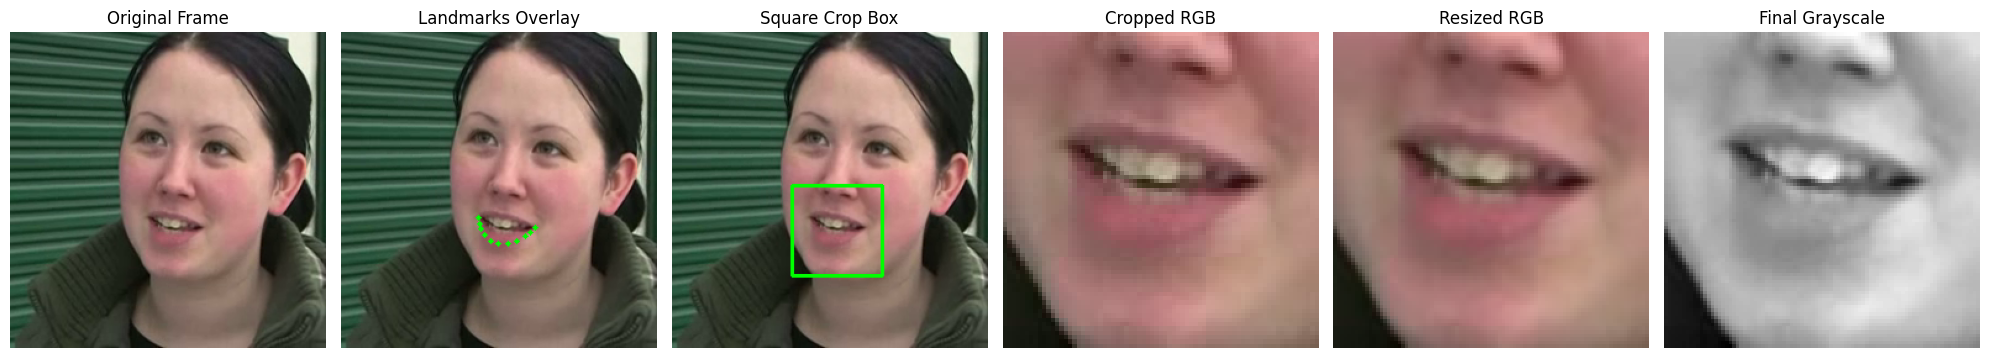


Visualization Cell Complete.


In [ ]:
print("\n--- Visualizing Preprocessing Stages ---")

if not os.path.exists(example_video_path):
    print("Cannot visualize: Example video file not found.")
else:
    cap = cv2.VideoCapture(example_video_path)
    if not cap.isOpened():
         print(f"Error: Could not open video file for visualization: {example_video_path}")
    else:
        # Select a frame to visualize (e.g., the middle frame)
        total_frames_in_video = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        frame_to_visualize_idx = total_frames_in_video // 2
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_to_visualize_idx)
        ret, frame = cap.read()
        cap.release()

        if not ret:
            print(f"Error: Could not read frame {frame_to_visualize_idx} for visualization.")
        else:
            print(f"Visualizing preprocessing for frame {frame_to_visualize_idx} of {example_video_path}")
            # Initialize Mediapipe Face Mesh just for this visualization
            mp_face_mesh = mp.solutions.face_mesh
            with mp_face_mesh.FaceMesh(static_image_mode=True, max_num_faces=1, refine_landmarks=False, min_detection_confidence=0.5) as face_mesh:
                intermediate_results = process_frame_with_intermediates(
                    frame,
                    face_mesh,
                    margin=FACE_MESH_MARGIN,
                    target_size=(IMG_WIDTH, IMG_HEIGHT)
                )

            if intermediate_results is None:
                print("Face or mouth landmarks not detected in the selected frame.")
            else:
                # Display the intermediate images
                fig, axes = plt.subplots(1, 6, figsize=(20, 4))

                axes[0].imshow(intermediate_results["original_frame_rgb"])
                axes[0].set_title("Original Frame")
                axes[0].axis("off")

                axes[1].imshow(intermediate_results["landmarks_overlay"])
                axes[1].set_title("Landmarks Overlay")
                axes[1].axis("off")

                axes[2].imshow(intermediate_results["original_with_sq_box"])
                axes[2].set_title("Square Crop Box")
                axes[2].axis("off")

                axes[3].imshow(intermediate_results["cropped_rgb"])
                axes[3].set_title("Cropped RGB")
                axes[3].axis("off")

                axes[4].imshow(intermediate_results["resized_rgb"])
                axes[4].set_title("Resized RGB")
                axes[4].axis("off")

                axes[5].imshow(intermediate_results["gray"], cmap='gray')
                axes[5].set_title("Final Grayscale")
                axes[5].axis("off")

                plt.tight_layout()
                plt.show()

print("\nVisualization Cell Complete.")

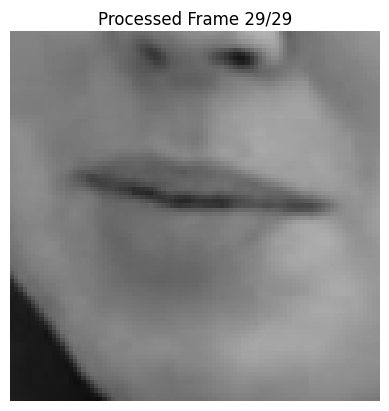

Animation finished.

Animation Cell Complete.


In [ ]:
print("\n--- Animating Processed Grayscale Video ---")

if 'processed_video' in locals() and processed_video is not None:
    print(f"Animating {processed_video.shape[0]} processed frames...")
    fig_anim, ax_anim = plt.subplots()
    for i in range(processed_video.shape[0]):
        clear_output(wait=True)
        ax_anim.imshow(processed_video[i].squeeze(), cmap='gray', vmin=0, vmax=255) # Ensure correct value range
        ax_anim.set_title(f"Processed Frame {i+1}/{processed_video.shape[0]}")
        ax_anim.axis("off")
        display(fig_anim)
        time.sleep(0.05) # Adjust speed if needed
    plt.close(fig_anim) # Close the figure after animation
    print("Animation finished.")
else:
    print("Skipping animation: 'processed_video' not found or is None (preprocessing might have failed).")

print("\nAnimation Cell Complete.")

In [ ]:
import json # Needed for saving/loading the map
import pickle # Alternative for saving Python lists directly

print("\n--- Gathering File Paths and Labels (with Persistence) ---")

save_dir = os.getcwd() # Use the current working directory (your Drive folder)
train_files_save_path = os.path.join(save_dir, "lrw_train_files.pkl")
train_labels_save_path = os.path.join(save_dir, "lrw_train_labels.pkl")
val_files_save_path = os.path.join(save_dir, "lrw_val_files.pkl")
val_labels_save_path = os.path.join(save_dir, "lrw_val_labels.pkl")
test_files_save_path = os.path.join(save_dir, "lrw_test_files.pkl")
test_labels_save_path = os.path.join(save_dir, "lrw_test_labels.pkl")
class_map_save_path = os.path.join(save_dir, "lrw_class_to_int_map.json")

# --- Function to save lists using pickle ---
def save_list_pickle(data_list, filepath):
    try:
        with open(filepath, 'wb') as f:
            pickle.dump(data_list, f)
        print(f"Saved list to {filepath}")
    except Exception as e:
        print(f"Error saving list to {filepath}: {e}")

# --- Function to load lists using pickle ---
def load_list_pickle(filepath):
    try:
        with open(filepath, 'rb') as f:
            data_list = pickle.load(f)
        print(f"Loaded list from {filepath}")
        return data_list
    except FileNotFoundError:
        print(f"File not found: {filepath}. Need to generate.")
        return None
    except Exception as e:
        print(f"Error loading list from {filepath}: {e}")
        return None

# --- Function to save dictionary as JSON ---
def save_dict_json(data_dict, filepath):
    try:
        with open(filepath, 'w') as f:
            json.dump(data_dict, f, indent=4)
        print(f"Saved dictionary to {filepath}")
    except Exception as e:
        print(f"Error saving dictionary to {filepath}: {e}")

# --- Function to load dictionary from JSON ---
def load_dict_json(filepath):
    try:
        with open(filepath, 'r') as f:
            data_dict = json.load(f)
        print(f"Loaded dictionary from {filepath}")
        return data_dict
    except FileNotFoundError:
        print(f"File not found: {filepath}. Need to generate.")
        return None
    except Exception as e:
        print(f"Error loading dictionary from {filepath}: {e}")
        return None

def get_files_and_labels(data_subset, current_lrw_root_path):
    subset_paths = []
    subset_labels = []
    class_to_int = {} # Ensure class_to_int is initialized

    lipread_dir = os.path.join(current_lrw_root_path, "lipread_mp4")
    if not os.path.isdir(lipread_dir):
        print(f"Error: 'lipread_mp4' directory not found in {current_lrw_root_path}")
        return None, None, None

    word_dirs = sorted([d for d in os.listdir(lipread_dir) if os.path.isdir(os.path.join(lipread_dir, d))])

    class_to_int = {word: i for i, word in enumerate(word_dirs)}
    num_found_classes = len(class_to_int)


    for word, label_int in class_to_int.items(): # Use tqdm outside if preferred
        word_subset_dir = os.path.join(lipread_dir, word, data_subset)
        if os.path.isdir(word_subset_dir):
            for filename in os.listdir(word_subset_dir):
                if filename.endswith(".mp4") and not filename.endswith("_mouth.mp4"):
                    video_path = os.path.join(word_subset_dir, filename)
                    subset_paths.append(video_path)
                    subset_labels.append(label_int)

    if not subset_paths:
        print(f"Warning/Info: No video files found for subset '{data_subset}'. Returning empty lists.")

    return subset_paths, subset_labels, class_to_int


# --- Main Logic: Try to load first, generate and save if necessary ---

print("\nAttempting to load existing file lists and map...")
train_files = load_list_pickle(train_files_save_path)
train_labels = load_list_pickle(train_labels_save_path)
val_files = load_list_pickle(val_files_save_path)
val_labels = load_list_pickle(val_labels_save_path)
test_files = load_list_pickle(test_files_save_path)
test_labels = load_list_pickle(test_labels_save_path)
class_to_int_map = load_dict_json(class_map_save_path)

# Check if all necessary components were loaded
all_loaded = all([
    train_files is not None, train_labels is not None,
    val_files is not None, val_labels is not None,
    test_files is not None, test_labels is not None,
    class_to_int_map is not None
])

if all_loaded:
    print("\nSuccessfully loaded all data from saved files.")
    # Quick sanity check on lengths
    if len(train_files) != len(train_labels) or len(val_files) != len(val_labels) or len(test_files) != len(test_labels):
         print("Warning: Loaded file and label list lengths do not match! Consider regenerating.")
    if len(class_to_int_map) != NUM_CLASSES:
         print(f"Warning: Loaded class map has {len(class_to_int_map)} entries, expected {NUM_CLASSES}. Consider regenerating.")

else:
    print("\nCould not load all data from files. Generating from scratch...")
    if 'lrw_root_path' not in locals():
         print("Error: lrw_root_path not defined. Please run the parameter cell first.")

    print("Generating train set...")
    train_files, train_labels, class_to_int_map = get_files_and_labels("train", lrw_root_path)
    print("Generating val set...")
    val_files, val_labels, _ = get_files_and_labels("val", lrw_root_path) # Reuse map from train
    print("Generating test set...")
    test_files, test_labels, _ = get_files_and_labels("test", lrw_root_path) # Reuse map from train

    # Save the newly generated data if generation was successful
    if train_files is not None and class_to_int_map is not None:
        print("\nSaving newly generated data...")
        save_list_pickle(train_files, train_files_save_path)
        save_list_pickle(train_labels, train_labels_save_path)
        save_list_pickle(val_files, val_files_save_path)
        save_list_pickle(val_labels, val_labels_save_path)
        save_list_pickle(test_files, test_files_save_path)
        save_list_pickle(test_labels, test_labels_save_path)
        save_dict_json(class_to_int_map, class_map_save_path)
    else:
        print("\nError during generation, data not saved.")


# --- Final Verification (Print counts like before) ---
if train_files:
    print(f"\nExample Training File: {train_files[0]}")
    print(f"Corresponding Label (int): {train_labels[0]}")
    if class_to_int_map:
        int_to_class_map = {v: k for k, v in class_to_int_map.items()}
        print(f"Corresponding Label (word): {int_to_class_map.get(train_labels[0], 'Unknown')}")
    print(f"Total Training Samples: {len(train_files)}")
if val_files:
    print(f"Total Validation Samples: {len(val_files)}")
if test_files:
    print(f"Total Test Samples: {len(test_files)}")
if class_to_int_map:
     print(f"\nClass mapping available with {len(class_to_int_map)} entries.")

print("\nFile Path Gathering Cell Complete (with Persistence).")


--- Gathering File Paths and Labels (with Persistence) ---

Attempting to load existing file lists and map...
File not found: /content/drive/MyDrive/lipreading/lrw/lrw_dataset/lrw_train_files.pkl. Need to generate.
File not found: /content/drive/MyDrive/lipreading/lrw/lrw_dataset/lrw_train_labels.pkl. Need to generate.
File not found: /content/drive/MyDrive/lipreading/lrw/lrw_dataset/lrw_val_files.pkl. Need to generate.
File not found: /content/drive/MyDrive/lipreading/lrw/lrw_dataset/lrw_val_labels.pkl. Need to generate.
File not found: /content/drive/MyDrive/lipreading/lrw/lrw_dataset/lrw_test_files.pkl. Need to generate.
File not found: /content/drive/MyDrive/lipreading/lrw/lrw_dataset/lrw_test_labels.pkl. Need to generate.
File not found: /content/drive/MyDrive/lipreading/lrw/lrw_dataset/lrw_class_to_int_map.json. Need to generate.

Could not load all data from files. Generating from scratch...
Generating train set...
Generating val set...
Generating test set...

Saving newly gene

In [ ]:
# Cell 10 (Rerun)

print("\n--- TensorFlow Data Pipeline Setup (Rerunning Wrapper Definition) ---")

# Define the function signature for the output of preprocess_video
output_signature = tf.TensorSpec(shape=(NUM_FRAMES, IMG_HEIGHT, IMG_WIDTH, 1), dtype=tf.uint8)

# Wrapper function to use preprocess_video within tf.data.map
@tf.function
def tf_preprocess_video_wrapper(video_path):
    """
    TensorFlow wrapper for the preprocess_video function.
    Takes a tensor video_path and returns the processed video tensor.
    """
    processed_video = tf.numpy_function(
        func=preprocess_video,
        inp=[video_path],             # Input tensors (video path, which is tf.string)
        Tout=tf.uint8
    )
    # Set the shape explicitly, as tf.numpy_function loses shape information.
    processed_video.set_shape(output_signature.shape)
    return processed_video

print("TensorFlow wrapper for preprocess_video redefined.")

# --- Test the wrapper (Optional but recommended) ---
if train_files:
    print("\nTesting tf_preprocess_video_wrapper...")
    # Ensure the path is passed as a tf.string tensor
    example_path_tensor = tf.constant(train_files[0], dtype=tf.string)
    try:
        # Eager execution or within tf.function context
        test_output = tf_preprocess_video_wrapper(example_path_tensor)
        print(f"Wrapper test successful. Output shape: {test_output.shape}, dtype: {test_output.dtype}")
    except Exception as e:
        print(f"Error testing wrapper function: {e}")
        import traceback
        traceback.print_exc()
else:
    print("Skipping wrapper test as no training files were found.")


--- TensorFlow Data Pipeline Setup (Rerunning Wrapper Definition) ---
TensorFlow wrapper for preprocess_video redefined.

Testing tf_preprocess_video_wrapper...
Wrapper test successful. Output shape: (29, 88, 88, 1), dtype: <dtype: 'uint8'>


cell 11

In [ ]:
print("\n--- Creating tf.data Datasets ---")

AUTOTUNE = tf.data.AUTOTUNE # Use tf AUTOTUNE for prefetch buffer size etc.

def create_dataset(file_paths, labels):
    """
    Creates a tf.data.Dataset from file paths and labels,
    applying preprocessing and normalization.
    """
    if not file_paths or not labels:
        print("Error: Cannot create dataset with empty file paths or labels.")
        return None

    # 1. Create dataset of file paths and labels
    path_ds = tf.data.Dataset.from_tensor_slices(file_paths)
    label_ds = tf.data.Dataset.from_tensor_slices(tf.cast(labels, dtype=tf.int32)) # Ensure labels are int32
    ds = tf.data.Dataset.zip((path_ds, label_ds))
    ds = ds.map(lambda path, label: (tf_preprocess_video_wrapper(path), label),
                num_parallel_calls=AUTOTUNE)


    # 4. Map Normalization and Type Conversion
    def normalize_and_cast(video, label):
        # Cast video to float32
        video = tf.cast(video, tf.float32)
        # Normalize pixel values from [0, 255] to [0, 1]
        video = video / 255.0
        return video, label

    ds = ds.map(normalize_and_cast, num_parallel_calls=AUTOTUNE)

    return ds

def configure_for_performance(ds, shuffle=False):
    """Applies shuffling, batching, and prefetching."""
    if shuffle:
        # Adjust buffer size according to dataset size and memory
        shuffle_buffer_size = min(len(train_files), 5000) # Shuffle buffer size
        print(f"Applying shuffle with buffer size: {shuffle_buffer_size}")
        ds = ds.shuffle(buffer_size=shuffle_buffer_size, reshuffle_each_iteration=True)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(buffer_size=AUTOTUNE)
    return ds

# Create the datasets
print("\nCreating Training Dataset...")
train_ds_raw = create_dataset(train_files, train_labels)
if train_ds_raw:
    train_ds = configure_for_performance(train_ds_raw, shuffle=True)
    print("Training dataset created.")

print("\nCreating Validation Dataset...")
val_ds_raw = create_dataset(val_files, val_labels)
if val_ds_raw:
    val_ds = configure_for_performance(val_ds_raw, shuffle=False) # No shuffling for validation
    print("Validation dataset created.")

print("\nCreating Test Dataset...")
test_ds_raw = create_dataset(test_files, test_labels)
if test_ds_raw:
    test_ds = configure_for_performance(test_ds_raw, shuffle=False) # No shuffling for test
    print("Test dataset created.")

print("\nDataset Creation Cell Complete.")


--- Creating tf.data Datasets ---

Creating Training Dataset...
Applying shuffle with buffer size: 5000
Training dataset created.

Creating Validation Dataset...
Validation dataset created.

Creating Test Dataset...
Test dataset created.

Dataset Creation Cell Complete.


In [ ]:
# Cell 13 (Corrected TimeDistributed and GAP)

print("\n--- Defining Model Architecture (Corrected TimeDistributed/GAP) ---")

from tensorflow.keras import layers
from tensorflow.keras.models import Model
import tensorflow as tf

# --- Positional Embedding (Keep as before) ---
class PositionalEmbedding(layers.Layer):
    # ... (definition remains the same) ...
    def __init__(self, sequence_length, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.position_embeddings = layers.Embedding(
            input_dim=sequence_length, output_dim=embed_dim
        )
        self.sequence_length = sequence_length
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim

    def call(self, x):
        length = tf.shape(x)[1]
        positions = tf.range(start=0, limit=length, delta=1)
        embedded_positions = self.position_embeddings(positions)
        return x + embedded_positions

    def get_config(self):
        config = super().get_config()
        config.update({
            "sequence_length": self.sequence_length,
            "vocab_size": self.vocab_size,
            "embed_dim": self.embed_dim,
        })
        return config


def transformer_encoder(embed_dim, num_heads, ff_dim, dropout_rate=0.1):
    inputs = layers.Input(shape=(None, embed_dim))
    attention_output = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=embed_dim // num_heads, dropout=dropout_rate
    )(inputs, inputs)
    x = layers.LayerNormalization(epsilon=1e-6)(inputs + attention_output)
    ffn = tf.keras.Sequential(
        [layers.Dense(ff_dim, activation="relu"), layers.Dense(embed_dim),]
    )
    ffn_output = ffn(x)
    ffn_output = layers.Dropout(dropout_rate)(ffn_output)
    x = layers.LayerNormalization(epsilon=1e-6)(x + ffn_output)
    return Model(inputs=inputs, outputs=x) # Removed explicit name


def resnet_identity_block(input_tensor, kernel_size, filters):
    filters1, filters2 = filters
    x = layers.Conv2D(filters1, (1, 1), kernel_initializer='he_normal', padding='same')(input_tensor)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(filters1, kernel_size, padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(filters2, (1, 1), kernel_initializer='he_normal', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.add([x, input_tensor])
    x = layers.Activation('relu')(x)
    return x


# --- ResNet Conv Block ---
def resnet_conv_block(input_tensor, kernel_size, filters, strides=(2, 2)):
    # ... (definition remains the same) ...
    filters1, filters2 = filters
    x = layers.Conv2D(filters1, (1, 1), strides=strides, kernel_initializer='he_normal', padding='same')(input_tensor)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(filters1, kernel_size, padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(filters2, (1, 1), kernel_initializer='he_normal', padding='same')(x)
    x = layers.BatchNormalization()(x)
    # Shortcut connection
    shortcut = layers.Conv2D(filters2, (1, 1), strides=strides, kernel_initializer='he_normal', padding='same')(input_tensor)
    shortcut = layers.BatchNormalization()(shortcut)
    x = layers.add([x, shortcut])
    x = layers.Activation('relu')(x)
    return x


def build_resnet18_core(input_shape, resnet18_filters=[64, 128, 256, 512], resnet18_blocks=[2, 2, 2, 2], resnet_kernel_size=(3, 3)):
    """Builds the core ResNet-18 layers, outputting feature maps."""
    resnet_input = layers.Input(shape=input_shape, name="resnet_core_input")
    x = resnet_input
    # Stage 1
    current_filters = resnet18_filters[0]
    x = resnet_conv_block(x, resnet_kernel_size, [current_filters, current_filters], strides=(1, 1))
    for _ in range(1, resnet18_blocks[0]):
        x = resnet_identity_block(x, resnet_kernel_size, [current_filters, current_filters])
    # Stage 2
    current_filters = resnet18_filters[1]
    x = resnet_conv_block(x, resnet_kernel_size, [current_filters, current_filters], strides=(2, 2))
    for _ in range(1, resnet18_blocks[1]):
        x = resnet_identity_block(x, resnet_kernel_size, [current_filters, current_filters])
    # Stage 3
    current_filters = resnet18_filters[2]
    x = resnet_conv_block(x, resnet_kernel_size, [current_filters, current_filters], strides=(2, 2))
    for _ in range(1, resnet18_blocks[2]):
        x = resnet_identity_block(x, resnet_kernel_size, [current_filters, current_filters])
    # Stage 4
    current_filters = resnet18_filters[3]
    x = resnet_conv_block(x, resnet_kernel_size, [current_filters, current_filters], strides=(2, 2))
    for _ in range(1, resnet18_blocks[3]):
        x = resnet_identity_block(x, resnet_kernel_size, [current_filters, current_filters])
    # Output here is (B, H_res, W_res, C_res) e.g. (B, 4, 4, 512)
    resnet_core = Model(inputs=resnet_input, outputs=x, name="resnet18_core")
    return resnet_core


# --- Build the Full Model (Corrected TimeDistributed & GAP) ---
def build_visual_conformer_classifier_final( # Renamed function again
    input_shape=INPUT_SHAPE,       # (T, H, W, C) = (29, 88, 88, 1)
    num_classes=NUM_CLASSES,       # 500
    # Frontend Params
    frontend_conv_filters=64,
    frontend_kernel_size=(5, 7, 7),
    frontend_strides=(1, 2, 2),
    frontend_pool_size=(1, 3, 3),
    frontend_pool_strides=(1, 2, 2),
    # ResNet Params
    resnet_filters=[64, 128, 256, 512],
    resnet_blocks=[2, 2, 2, 2],
    # Backend Params
    transformer_embed_dim=256,
    num_transformer_blocks=6,
    num_transformer_heads=4,
    transformer_ff_dim=1024,
    transformer_dropout=0.1,
    # Classifier Head Params
    mlp_units=[128],
    mlp_dropout=0.3
    ):

    inputs = layers.Input(shape=input_shape, name="video_input") # (B, T, H, W, C)

    # --- Visual Frontend ---
    # Input: (B, 29, 112, 112, 1)
    x = layers.Conv3D(
        filters=frontend_conv_filters, kernel_size=frontend_kernel_size,
        strides=frontend_strides, padding='same', name='frontend_conv3d')(inputs)
    x = layers.BatchNormalization(name='frontend_bn')(x)
    x = layers.Activation('relu', name='frontend_relu')(x)
    # Shape: (B, 29, 56, 56, 64)
    x = layers.MaxPool3D(
        pool_size=frontend_pool_size, strides=frontend_pool_strides,
        padding='same', name='frontend_maxpool3d')(x)
    # Output shape: (B, T=29, H'=28, W'=28, C'=64)

    # --- ResNet Backbone  ---
    resnet_input_shape = x.shape[2:]
    resnet_core = build_resnet18_core(resnet_input_shape, resnet18_filters=resnet_filters, resnet18_blocks=resnet_blocks)

    # Wrap the ResNet core (outputs feature maps) with TimeDistributed
    x = layers.TimeDistributed(resnet_core, name='timedist_resnet18')(x)
    # Output shape: (B, T=29, H_res=4, W_res=4, C_res=512)

    # --- Pooling & Feature Projection ---
    # Apply GlobalAveragePooling2D to the output of each time step.
    # Need to reshape, apply GAP2D, then reshape back OR use TimeDistributed(GAP2D)

    # Option 1: Reshape -> GAP2D -> Reshape (Potentially clearer)
    # _, T, H_res, W_res, C_res = x.shape
    # x = layers.Reshape((-1, H_res, W_res, C_res), name='reshape_for_gap')(x) # (B*T, H_res, W_res, C_res)
    # x = layers.GlobalAveragePooling2D(name='gap_2d_frames')(x) # (B*T, C_res)
    # x = layers.Reshape((-1, T, C_res), name='reshape_after_gap')(x) # (B, T, C_res) e.g. (B, 29, 512)

    # Option 2: TimeDistributed(GAP2D) (More concise if it works)
    gap_layer = layers.GlobalAveragePooling2D(name='gap_2d_layer')
    x = layers.TimeDistributed(gap_layer, name='timedist_gap')(x)
    # Output shape: (B, T=29, C_res=512)

    # Now x is (B, T, Features_per_frame)

    resnet_output_filters = resnet_filters[-1] # 512 (or C_res)
    if resnet_output_filters != transformer_embed_dim:
         x = layers.Dense(transformer_embed_dim, name='feature_projection')(x) # Project (B, T, 512) -> (B, T, 256)

    # --- Temporal Backend (Transformer) ---
    # Add Positional Embedding
    x = PositionalEmbedding(NUM_FRAMES, NUM_CLASSES, transformer_embed_dim, name='positional_embedding')(x)
    x = layers.Dropout(transformer_dropout, name='pos_embedding_dropout')(x)

    # Stack Transformer Encoder Blocks
    for i in range(num_transformer_blocks):
        # Give each encoder block a unique name
        encoder_layer = transformer_encoder(
            embed_dim=transformer_embed_dim,
            num_heads=num_transformer_heads,
            ff_dim=transformer_ff_dim,
            dropout_rate=transformer_dropout
        )
        x = encoder_layer(x)

    # --- Classification Head ---
    x = layers.GlobalAveragePooling1D(name='temporal_global_avg_pool')(x) # (B, transformer_embed_dim)

    for i, units in enumerate(mlp_units):
         x = layers.Dense(units, activation='relu', name=f'mlp_dense_{i+1}')(x)
         x = layers.Dropout(mlp_dropout, name=f'mlp_dropout_{i+1}')(x)

    outputs = layers.Dense(num_classes, activation='softmax', name='classifier_output')(x)

    # Create Model
    model = Model(inputs=inputs, outputs=outputs)
    return model

# --- Instantiate and Summarize ---
tf.keras.backend.clear_session()
# Use the final builder function name
lipreading_model = build_visual_conformer_classifier_final()
lipreading_model.summary(expand_nested=True)

print("\nModel Definition Cell Complete (Corrected TimeDistributed/GAP).")


--- Defining Model Architecture (Corrected TimeDistributed/GAP) ---


Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ video_input (InputLayer)             │ (None, 29, 88, 88, 1)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ frontend_conv3d (Conv3D)             │ (None, 29, 44, 44, 64)      │          15,744 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ frontend_bn (BatchNormalization)     │ (None, 29, 44, 44, 64)      │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ frontend_relu (Activation)           │ (None, 29, 44, 44, 64)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ frontend_maxpool3d (MaxPooling3D)    │ (None, 29, 22, 22, 64)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ timedist_resnet18 (TimeDistributed)  │ (None, 29, 3, 3, 512)       │       7,697,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ timedist_gap (TimeDistributed)       │ (None, 29, 512)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ feature_projection (Dense)           │ (None, 29, 256)             │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ positional_embedding                 │ (None, 29, 256)             │           7,424 │
│ (PositionalEmbedding)                │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pos_embedding_dropout (Dropout)      │ (None, 29, 256)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ functional_1 (Functional)            │ (None, 29, 256)             │         789,760 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ input_layer (InputLayer)        │ (None, None, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ multi_head_attention            │ (None, None, 256)           │         263,168 │
│ (MultiHeadAttention)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ layer_normalization             │ (None, None, 256)           │             512 │
│ (LayerNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ sequential (Sequential)         │ (None, None, 256)           │         525,568 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│       └ dense (Dense)                │ (None, None, 1024)          │         263,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│       └ dense_1 (Dense)              │ (None, None, 256)           │         262,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ dropout_1 (Dropout)             │ (None, None, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ layer_normalization_1           │ (None, None, 256)           │             512 │
│ (LayerNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 12,687,924 (48.40 MB)

 Trainable params: 12,674,356 (48.35 MB)

 Non-trainable params: 13,568 (53.00 KB)


Model Definition Cell Complete (Corrected TimeDistributed/GAP).


In [ ]:
print("\n--- Compiling Model and Setting Up Callbacks ---")

# --- Optimizer ---
initial_learning_rate = 1e-4 # Starting learning rate (adjust as needed)
# Example: Exponential Decay Schedule
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate,
    decay_steps=len(train_ds) * 5, # Decay every 5 epochs (adjust steps based on dataset size)
    decay_rate=0.90, # Decay rate (adjust as needed)
    staircase=True)



optimizer = tf.keras.optimizers.AdamW(
    learning_rate=lr_schedule,
    weight_decay=1e-5
)
print(f"Using Optimizer: AdamW with scheduled LR starting at {initial_learning_rate}")

# --- Loss Function ---
# Since labels are integers (0-499), use SparseCategoricalCrossentropy
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False) # False because model output has softmax
print(f"Using Loss: SparseCategoricalCrossentropy")

# --- Metrics ---
# Track accuracy during training and validation
metrics_list = [tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy')]
print(f"Using Metrics: SparseCategoricalAccuracy")

# --- Compile the Model ---
lipreading_model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=metrics_list
)
print("\nModel Compiled Successfully.")


# --- Callbacks ---
# Define paths for saving checkpoints and logs (use Drive path)
checkpoint_dir = os.path.join(lrw_root_path, "training_checkpoints_tf")
log_dir = os.path.join(lrw_root_path, "logs_tf") # Subdir for TensorBoard logs

os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(log_dir, exist_ok=True)

print(f"\nCheckpoints will be saved in: {checkpoint_dir}")
print(f"TensorBoard logs will be saved in: {log_dir}")

# 1. ModelCheckpoint Callback
# Save weights only, monitor validation accuracy, save the best model
checkpoint_filepath = os.path.join(checkpoint_dir, "ckpt-epoch_{epoch:02d}-val_acc_{val_accuracy:.3f}.weights.h5")
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_accuracy',  # Monitor validation accuracy
    mode='max',              # Save when validation accuracy is maximal
    save_best_only=True,    # Only save the best model found so far
    save_weights_only=True, # Save only weights (more portable)
    verbose=1                # Print message when saving
)
print("ModelCheckpoint callback configured to save best weights based on val_accuracy.")

# 2. TensorBoard Callback
tensorboard_callback = tf.keras.callbacks.TensorBoard(
    log_dir=log_dir,
    histogram_freq=1,
    write_graph=True,
    update_freq='epoch'
)
print("TensorBoard callback configured.")

# 3. EarlyStopping Callback (Optional)
# Stop training if validation accuracy doesn't improve for 'patience' epochs
early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,          # Number of epochs with no improvement after which training stops
    verbose=1,
    mode='max',
    restore_best_weights=True # Restore model weights from the epoch with the best val_accuracy
)
print("EarlyStopping callback configured with patience=10 on val_accuracy.")


# Combine callbacks into a list
training_callbacks = [
    model_checkpoint_callback,
    tensorboard_callback,
    # early_stopping_callback # Uncomment to enable early stopping
]
print("\nCallback Setup Complete.")


--- Compiling Model and Setting Up Callbacks ---
Using Optimizer: AdamW with scheduled LR starting at 0.0001
Using Loss: SparseCategoricalCrossentropy
Using Metrics: SparseCategoricalAccuracy

Model Compiled Successfully.

Checkpoints will be saved in: /content/drive/MyDrive/lipreading/lrw/lrw_dataset/training_checkpoints_tf
TensorBoard logs will be saved in: /content/drive/MyDrive/lipreading/lrw/lrw_dataset/logs_tf
ModelCheckpoint callback configured to save best weights based on val_accuracy.
TensorBoard callback configured.
EarlyStopping callback configured with patience=10 on val_accuracy.

Callback Setup Complete.


In [ ]:
print("\n--- Starting Model Training ---")

# --- Training Hyperparameters ---
NUM_EPOCHS = 20 # Set the total number of epochs (adjust as needed)
# Can start with fewer epochs (e.g., 5-10) to test the loop first

# Optional: If you want to limit steps per epoch (e.g., for faster testing)
# STEPS_PER_EPOCH = len(train_ds) # Use full dataset
# STEPS_PER_EPOCH = 1000 # Example: limit to 1000 steps

# Optional: Limit validation steps
# VALIDATION_STEPS = len(val_ds) # Use full validation set
# VALIDATION_STEPS = 200 # Example: limit validation steps

# --- Start Training ---
# Ensure datasets are available
if 'train_ds' in locals() and 'val_ds' in locals() and train_ds is not None and val_ds is not None:

    print(f"Training for {NUM_EPOCHS} epochs...")
    print(f"Using Training Dataset: {train_ds.cardinality().numpy()} batches (approx)") # Use .cardinality() for TF > 2.8
    print(f"Using Validation Dataset: {val_ds.cardinality().numpy()} batches (approx)")

    start_train_time = time.time()

    history = lipreading_model.fit(
        train_ds,
        epochs=NUM_EPOCHS,
        validation_data=val_ds,
        # steps_per_epoch=STEPS_PER_EPOCH, # Uncomment to limit steps
        # validation_steps=VALIDATION_STEPS, # Uncomment to limit validation steps
        callbacks=training_callbacks, # Pass the list of callbacks we defined
        verbose=1 # Set to 1 for progress bar, 2 for one line per epoch, 0 for silent
    )

    end_train_time = time.time()
    print(f"\nTraining finished in {(end_train_time - start_train_time) / 60:.2f} minutes.")

    # --- Plot Training History (Optional) ---
    if history and history.history:
        print("\nPlotting training history...")
        plt.figure(figsize=(12, 5))

        # Plot Accuracy
        plt.subplot(1, 2, 1)
        plt.plot(history.history['accuracy'], label='Training Accuracy')
        plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
        plt.title('Model Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(True)

        # Plot Loss
        plt.subplot(1, 2, 2)
        plt.plot(history.history['loss'], label='Training Loss')
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.title('Model Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.show()

        # Print best validation accuracy achieved
        best_val_acc = max(history.history['val_accuracy'])
        print(f"Best Validation Accuracy achieved: {best_val_acc:.4f}")

else:
    print("Error: Training dataset ('train_ds') or Validation dataset ('val_ds') not found or is None. Cannot start training.")

print("\nTraining Cell Complete.")


--- Starting Model Training ---
Training for 20 epochs...
Using Training Dataset: 3819 batches (approx)
Using Validation Dataset: 196 batches (approx)
Epoch 1/20
 392/3819 ━━━━━━━━━━━━━━━━━━━━ 69:08:53 73s/step - accuracy: 0.0929 - loss: 4.6458

In [ ]:
# print("\n--- Verifying Data Pipeline Output ---")
#
# if 'train_ds' in locals() and train_ds is not None:
#     print("Checking one batch from the training dataset...")
#     try:
#         for video_batch, label_batch in train_ds.take(1): # Take just one batch
#             print("Video Batch Shape:", video_batch.shape)
#             print("Label Batch Shape:", label_batch.shape)
#             print("Video Batch dtype:", video_batch.dtype)
#             print("Label Batch dtype:", label_batch.dtype)
#             print("Video Batch Min/Max:", tf.reduce_min(video_batch).numpy(), tf.reduce_max(video_batch).numpy())
#             print("Example Labels:", label_batch.numpy()[:5])
#
#             # Visualize the middle frame of the first video in the batch
#             plt.figure(figsize=(4, 4))
#             plt.imshow(video_batch[0, NUM_FRAMES // 2, :, :, 0].numpy(), cmap='gray') # Access frame: [batch_idx, frame_idx, :, :, channel_idx]
#             plt.title(f"Processed Frame from Pipeline (Label: {label_batch[0].numpy()})")
#             plt.axis("off")
#             plt.show()
#             break # Only need one batch
#
#     except tf.errors.OutOfRangeError:
#         print("Could not take a batch from the training dataset (maybe empty?).")
#     except Exception as e:
#         print(f"An error occurred while verifying the training dataset: {e}")
#         import traceback
#         traceback.print_exc()
#
# else:
#     print("Training dataset ('train_ds') not available for verification.")
#
# # Optional: Verify validation dataset too
# # if 'val_ds' in locals() and val_ds is not None:
# #     print("\nChecking one batch from the validation dataset...")
# #     # ... (similar verification code) ...
#
# print("\nData Pipeline Verification Cell Complete.")